In [1]:
import sys
from pathlib import Path
#!{sys.executable} -m pip install pyradiomics

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import sys
print(sys.executable)

c:\Users\emili\Desktop\Bone-Age-Regression-from-Hand-X-Ray-Images\.venvML\Scripts\python.exe


In [ ]:
from src.utils.dataframe_utils import create_dataframe

#Let's use the segmented data in grayscale

df_train = create_dataframe("../data/train.csv", "../data/boneage-training-segmented-gray", segmented=True)



In [ ]:
import cv2
import numpy as np
import SimpleITK as sitk
from matplotlib import pyplot as plt


In [ ]:
def load_segmented_for_radiomics(path):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = (img > 0).astype(np.uint8)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)  
    image_sitk = sitk.GetImageFromArray(img.astype(np.float32))
    mask_sitk = sitk.GetImageFromArray(mask.astype(np.uint8))

    return image_sitk, mask_sitk



In [20]:
#let's use pyradiomics feature extractor
from radiomics import featureextractor

extractor = featureextractor.RadiomicsFeatureExtractor()

extractor.disableAllFeatures()

extractor.enableFeatureClassByName("firstorder")
extractor.enableFeatureClassByName("glcm")
extractor.enableFeatureClassByName("glrlm")

extractor.settings["force2D"] = True
extractor.settings["label"] = 1


In [ ]:
from tqdm import tqdm
import pandas as pd

all_features = []

for idx, row in tqdm(df_train.iterrows(),
                     total=len(df_train),
                     desc="Extracting radiomics features"):

    image, mask = load_segmented_for_radiomics(row["path"])

    result = extractor.execute(image, mask, label=1)

    features = {
    k: float(v)
    for k, v in result.items()
    if k.startswith("original_")
    }

    features_50 = dict(list(features.items())[:50])

    features_50["id"] = row["id"]
    features_50["boneage"] = row["boneage"]
    features_50["male"] = row["male"]

    all_features.append(features_50)

features_df = pd.DataFrame(all_features)
features_df.to_csv("radiomics_features.csv", index=False)

Extracting radiomics features: 100%|██████████| 12611/12611 [1:04:24<00:00,  3.26it/s]


In [67]:
import pandas as pd

features_df = pd.read_csv("model_results/radiomics_features.csv")
features_df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,id,boneage,male
0,72.0,168.0,304822346.0,2.632600,62.0,2.843072,211.0,33.208516,120.196838,124.0,...,0.149814,3.571695,28.776324,20.044512,676.094767,0.845257,0.108675,1377,180,False
1,105.0,206.0,650653685.0,2.156617,86.0,2.367790,246.0,41.524579,156.831580,184.0,...,0.126614,5.415195,37.240447,858.853028,37268.975309,25.490230,0.119206,1378,12,False
2,171.0,210.0,424314235.0,1.752630,24.0,17.983630,232.0,18.892210,185.279200,191.0,...,0.205922,5.408624,52.851003,61.876381,4341.801883,1.310949,0.101619,1379,94,False
3,60.0,129.0,170175972.0,2.221255,38.0,3.552221,172.0,22.204957,95.158907,98.0,...,0.190222,2.115474,17.250181,36.069414,814.536033,2.000890,0.150070,1380,120,True
4,165.0,190.0,295409756.0,1.315762,14.0,20.334487,201.0,15.248489,172.685220,180.0,...,0.246160,5.049305,40.418780,204.115147,12877.575737,3.663537,0.131418,1381,82,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12606,45.0,158.0,226111949.0,2.814788,63.0,2.813887,228.0,34.909366,95.496757,91.0,...,0.142523,3.851950,19.617323,38.287802,995.343287,2.522728,0.184314,15605,50,False
12607,36.0,167.0,209891193.0,2.923394,72.0,2.428369,228.0,39.743232,95.297770,89.0,...,0.132731,4.412856,20.909323,28.333192,736.431514,2.368634,0.197753,15606,113,False
12608,39.0,149.0,140235104.0,2.777076,64.0,2.623315,227.0,34.715579,89.647622,86.0,...,0.143596,3.751142,19.117782,23.847726,524.425396,2.033370,0.188450,15608,55,False
12609,31.0,151.0,132102351.0,2.824607,68.0,2.660362,226.0,37.313651,85.287882,79.0,...,0.139580,4.272744,18.928449,31.681454,648.007728,3.320411,0.219443,15609,150,True


Let's tune the iperparameters of the model

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
#reduce the dataset to accelerate the tuning 
features_small = features_df.sample(
    n=3000,
    random_state=42
)

In [54]:
X_small = features_small.drop(columns=["id", "boneage"])
y_small = features_small["boneage"]


In [55]:
X_train, X_val, y_train, y_val = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

In [68]:
n_trees = [ 300, 500, 800, 1000, 1200]

mae_list = []

for n in n_trees:

    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)

    mae_list.append(mae)

    print(f"{n} alberi -> MAE = {mae:.2f}")

300 alberi -> MAE = 24.43
500 alberi -> MAE = 24.41
800 alberi -> MAE = 24.34
1000 alberi -> MAE = 24.34
1200 alberi -> MAE = 24.36


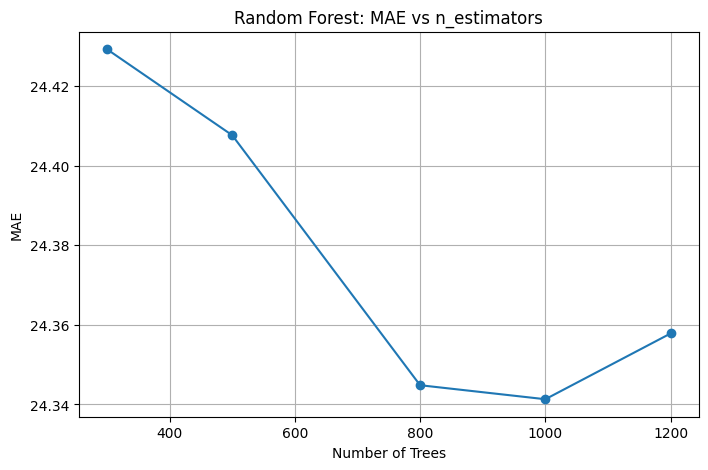

In [69]:
plt.figure(figsize=(8,5))

plt.plot(n_trees, mae_list, marker="o")

plt.xlabel("Number of Trees")
plt.ylabel("MAE")
plt.title("Random Forest: MAE vs n_estimators")

plt.grid(True)

plt.show()

In [59]:
depths = [None, 5, 10, 15, 20, 30, 40]

mae_list = []

for d in depths:

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_val)

    mae_list.append(mean_absolute_error(y_val, pred))
    print(f"{d} depths -> MAE = {mae:.2f}")

None depths -> MAE = 24.34
5 depths -> MAE = 24.34
10 depths -> MAE = 24.34
15 depths -> MAE = 24.34
20 depths -> MAE = 24.34
30 depths -> MAE = 24.34
40 depths -> MAE = 24.34


In [ ]:
#we can also add a grid search

Now that we tuned the iperparameters, we train the model on all the dataset available in the folder data/boneage-training-segmented-gray

In [26]:
X = features_df.drop(columns=["id", "boneage"])
y = features_df["boneage"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Random forest with tuned iperparametrs

rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [30]:
y_pred = rf.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 23.515707491082047
RMSE: 29.931687956026607
R2: 0.49419541841412595


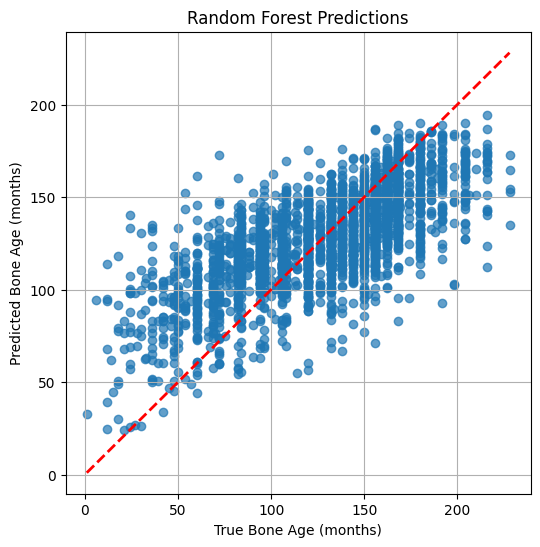

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# retta ideale
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel("True Bone Age (months)")
plt.ylabel("Predicted Bone Age (months)")
plt.title("Random Forest Predictions")

plt.grid(True)

plt.show()

Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1,
    return_train_score=True
)

In [39]:
mae = -scores["test_MAE"]
rmse = -scores["test_RMSE"]
r2 = scores["test_R2"]

print("MAE per fold:", mae)
print("RMSE per fold:", rmse)
print("R² per fold:", r2)

print("\nMedia ± std")
print(f"MAE : {mae.mean():.2f} ± {mae.std():.2f}")
print(f"RMSE: {rmse.mean():.2f} ± {rmse.std():.2f}")
print(f"R²  : {r2.mean():.3f} ± {r2.std():.3f}")

MAE per fold: [23.49155688 23.04682157 22.75469548 23.11240603 24.00807772]
RMSE per fold: [29.91584645 29.73415947 29.0292269  29.38622002 30.73634216]
R² per fold: [0.49473068 0.47811095 0.49752617 0.48114231 0.43468201]

Media ± std
MAE : 23.28 ± 0.43
RMSE: 29.76 ± 0.57
R²  : 0.477 ± 0.023


It is also interesting to investigate which of the 50 features are the most influential in the model's predictions. To this end, we evaluated feature importance using two different approaches: Random Forest feature importance and permutation feature importance.

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)



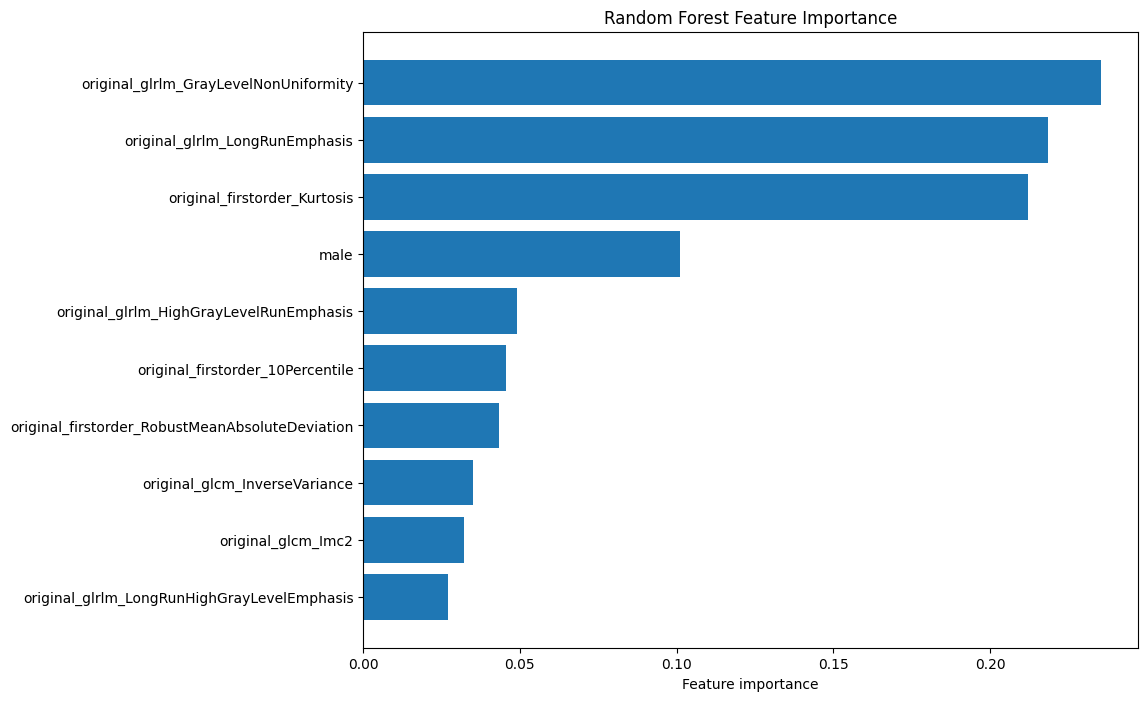

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [44]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [49]:
importance_per = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

importance_per.sort_values(
    "Importance",
    ascending=False,
    inplace=True
)


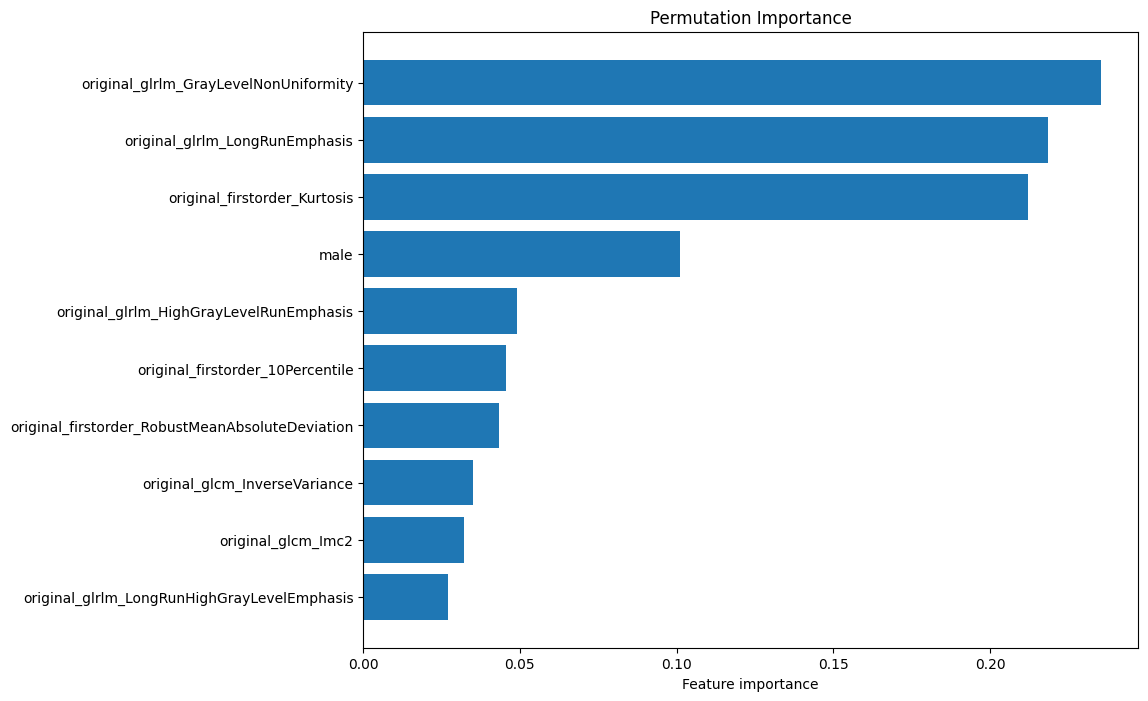

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance_per.head(10)["Feature"],
    importance_per.head(10)["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature importance")
plt.title("Permutation Importance")

plt.show()